# Outward Premium Range — Exploration

**Question (Q3):** what drives the *range* we show beside the outward premium, and does it behave?

**Hypothesis (a):** the range is a **Poisson confidence band on the qualifying-event count K** —
λ(T) is estimated from K outages of ≥ T hours over ~11 years; a Poisson interval on K, carried
through the premium, gives the band. Tested here against **(b)** the per-customer multiplier spread.

Face-validity targets: the band should be **tight where K is large** (data-rich) and **widen where K
is small / T is long**. Design note: `docs/dicsscssion/dashboard_redesign/07_outward_range.md`.

In [1]:
import json, pathlib
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import chi2

base = pathlib.Path("../../price_engine/catalogs/eagle-i-45min/pricing")
dd = json.load(open(base / "county_drilldown.json"))
pc = json.load(open(base / "per_customer_view.json"))["view"]

ER, TM = 0.20, 0.15
DENOM = 1 - ER - TM
X = 2500  # reference payout
print(f"{len(dd)} counties · X=${X} · ER={ER} TM={TM} · denom={DENOM:.2f}")

3090 counties · X=$2500 · ER=0.2 TM=0.15 · denom=0.65


In [2]:
def pois_ci(k, conf):
    """Exact (Garwood) Poisson CI on a count k."""
    a = 1 - conf
    lo = chi2.ppf(a / 2, 2 * k) / 2 if k > 0 else 0.0
    hi = chi2.ppf(1 - a / 2, 2 * k + 2) / 2
    return lo, hi

def premium(lam):
    return lam * X / DENOM

def band_a(K, lam, conf=0.80):
    """Relative Poisson band on K -> premium band (point, low, high, width%)."""
    p = premium(lam)
    if K <= 0 or p == 0:
        return p, float("nan"), float("nan"), float("nan")
    lo, hi = pois_ci(K, conf)
    plo, phi = p * lo / K, p * hi / K
    return p, plo, phi, (phi - plo) / p * 100

def cells_for(T):
    out = []
    for fips, c in dd.items():
        e = pc.get(fips, {}).get(T)
        if not e or e.get("coverage_gate_status") != "available":
            continue
        K = e.get("n_events_qualifying") or 0
        lam = e.get("lambda_customer_mean")
        if lam is None:
            continue
        out.append(dict(fips=fips, name=f'{c["county"]}, {c["state"]}', K=K, lam=lam,
                        lmed=e.get("lambda_customer_median"), lmax=e.get("lambda_customer_max")))
    return out

## 1. Spectrum at T = 8h — the band tightens as K grows

Representative counties across the K distribution. Width should fall monotonically as K rises.

In [3]:
T = "8"
rows = sorted(cells_for(T), key=lambda r: r["K"])
n = len(rows)
recs = []
for lab, q in [("p05",.05),("p25",.25),("p50",.50),("p75",.75),("p95",.95),("max",.999)]:
    r = rows[min(int(q*n), n-1)]
    p, lo, hi, w = band_a(r["K"], r["lam"], 0.80)
    recs.append(dict(pct=lab, county=r["name"], K=r["K"], premium=round(p),
                     band=f"${lo:,.0f}-${hi:,.0f}", width_pct=round(w)))
spectrum = pd.DataFrame(recs)
print(f"T={T}h · {n} quotable counties")
spectrum

T=8h · 2273 quotable counties


,pct,county,K,premium,band,width_pct
0,p05,"Clayton, IA",116,153,$135-$173,25
1,p25,"Lawrence, MS",206,1600,"$1,459-$1,752",18
2,p50,"Daviess, KY",399,204,$191-$218,13
3,p75,"Garvin, OK",864,383,$366-$400,9
4,p95,"Jefferson, LA",2101,542,$527-$558,6
5,max,"Pasco, FL",3103,320,$312-$327,5


## 2. Across the trigger (Alachua FL) — the band widens as history thins

Same county, every trigger duration. Longer trigger → fewer qualifying events → wider band. This is
the same signal as the Studio's comfort-by-trigger strip.

In [4]:
fips = "12001" if "12001" in dd else rows[-1]["fips"]
yr = dd[fips]["observation_years"]
recs = []
for t in ["2","4","8","12","24"]:
    e = pc.get(fips, {}).get(t)
    if not e: continue
    K = e.get("n_events_qualifying") or 0
    lam = e.get("lambda_customer_mean")
    if lam is None: continue
    p, lo, hi, w = band_a(K, lam, 0.80)
    recs.append(dict(T=t+"h", K=K, premium=round(p), band=f"${lo:,.0f}-${hi:,.0f}", width_pct=round(w)))
print(f'{dd[fips]["county"]}, {dd[fips]["state"]} ({fips}) · obs_years={yr:.1f}')
pd.DataFrame(recs)

Alachua, FL (12001) · obs_years=11.2


,T,K,premium,band,width_pct
0,2h,5954,545,$536-$555,3
1,4h,3430,394,$385-$403,4
2,8h,1546,244,$236-$252,7
3,12h,679,171,$163-$180,10
4,24h,163,107,$97-$119,21


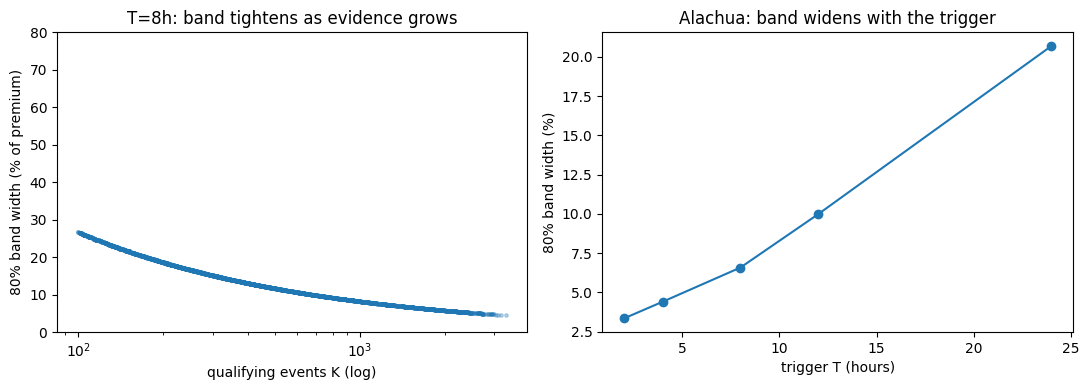

In [5]:
# the shape: band width vs K (all quotable counties at T=8) -> the 1/sqrt(K) decay
data = [(r["K"], band_a(r["K"], r["lam"], 0.80)[3]) for r in rows if r["K"] > 0]
Ks, Ws = zip(*data)
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].scatter(Ks, Ws, s=6, alpha=0.3)
ax[0].set_xscale("log"); ax[0].set_xlabel("qualifying events K (log)"); ax[0].set_ylabel("80% band width (% of premium)")
ax[0].set_title("T=8h: band tightens as evidence grows"); ax[0].set_ylim(0, 80)
ax[1].plot([2,4,8,12,24], [band_a((pc[fips].get(str(t)) or {}).get("n_events_qualifying") or 0,
            (pc[fips].get(str(t)) or {}).get("lambda_customer_mean") or float("nan"), 0.80)[3]
           for t in [2,4,8,12,24]], "o-")
ax[1].set_xlabel("trigger T (hours)"); ax[1].set_ylabel("80% band width (%)")
ax[1].set_title(f'{dd[fips]["county"]}: band widens with the trigger')
plt.tight_layout(); plt.show()

## 3. (a) confidence  vs  (b) heterogeneity — two DIFFERENT uncertainties (not rivals)

They answer different questions. **(a) Poisson-on-K** = *how sure are we of the county's average
rate* — shrinks as we see more events. **(b) median..max** = *how much frequency varies by location
within the county* — real structural spread, **huge even for data-rich counties** and wildly
asymmetric. So (b) is not a confidence band; it's the **heterogeneity backdrop** that the location
adjustment resolves to a point for a specific address. The table below shows (b) stays large
regardless of K — proof it isn't measuring confidence.

In [6]:
recs = []
for r in [rows[int(.5*n)], rows[int(.05*n)], rows[-1]]:
    p, lo, hi, wa = band_a(r["K"], r["lam"], 0.80)
    pmed, pmax = premium(r["lmed"] or r["lam"]), premium(r["lmax"] or r["lam"])
    wb = (pmax - pmed) / p * 100 if p else float("nan")
    recs.append(dict(county=r["name"], K=r["K"],
                     a_width_pct=round(wa), b_spread=f"${pmed:,.0f}..${pmax:,.0f}", b_width_pct=round(wb)))
pd.DataFrame(recs)

,county,K,a_width_pct,b_spread,b_width_pct
0,"Daviess, KY",399,13,"$34..$1,333",637
1,"Clayton, IA",116,25,$29..$733,460
2,"Wake, NC",3305,4,"$1,208..$28,736",748


In [7]:
# confidence-level sensitivity: 80% vs 90% on a mid county
r = rows[int(.5*n)]
for conf in (0.80, 0.90):
    p, lo, hi, w = band_a(r["K"], r["lam"], conf)
    print(f'{r["name"]:24s} {int(conf*100)}%  ${lo:,.0f}-${hi:,.0f}  (+/-{w:.0f}% of ${p:,.0f})')

Daviess, KY              80%  $191-$218  (+/-13% of $204)
Daviess, KY              90%  $187-$222  (+/-17% of $204)


## 4. The decisive test — do outages CLUSTER enough that Poisson is too tight?

Poisson-on-K assumes outages arrive independently. They don't — storms bundle them. We measure the
**dispersion index** (var/mean of annual counts; >1 = clustered) on the masked annual series, and
compare a **year-based bootstrap** band (resample observed annual rates) to Poisson.

In [8]:
disp = pd.read_parquet("../../curated_outage_data/outputs/county_trend/county_yearly_trend__eagle-i-45min.parquet")
def _obs(row):
    yc = np.asarray(row["yearly_counts"], float); mk = np.asarray(row["observed_year_mask"], bool)
    return yc[mk] if len(mk) == len(yc) else yc
def _disp(c):
    return c.var(ddof=1) / c.mean() if len(c) >= 2 and c.mean() > 0 else np.nan
rows_d = []
for t in [2, 4, 8, 12, 24]:
    s = disp[disp["T"] == t]
    Ds = np.array([d for d in (_disp(_obs(r)) for _, r in s.iterrows() if r["observed_year_count"] >= 5) if not np.isnan(d)])
    rows_d.append(dict(T=f"{t}h", median_var_over_mean=round(float(np.median(Ds)), 1), pct_overdispersed=f"{(Ds>1).mean()*100:.0f}%"))
print("Dispersion of annual counts (var/mean; >1 => clustered => Poisson understates):")
pd.DataFrame(rows_d)

Dispersion of annual counts (var/mean; >1 => clustered => Poisson understates):


,T,median_var_over_mean,pct_overdispersed
0,2h,12.6,98%
1,4h,9.0,97%
2,8h,5.0,94%
3,12h,3.2,91%
4,24h,1.8,81%


In [9]:
# year-based bootstrap band vs Poisson, overall at T=8h
np.random.seed(7)
def _ybw(c, conf=0.80, B=2000):
    if len(c) < 2 or c.mean() <= 0: return np.nan
    m = c[np.random.randint(0, len(c), size=(B, len(c)))].mean(1)
    lo, hi = np.percentile(m, [(1-conf)/2*100, (1+conf)/2*100]); return (hi - lo) / c.mean()
def _pw(K, conf=0.80):
    if K <= 0: return np.nan
    a = 1 - conf; return (chi2.ppf(1-a/2, 2*K+2)/2 - chi2.ppf(a/2, 2*K)/2) / K
t8 = disp[(disp["T"] == 8) & (disp["observed_year_count"] >= 5)]
ratios = []
for _, r in t8.iterrows():
    c = _obs(r); K = int(r["total_events_in_window"]); pw, yw = _pw(K), _ybw(c)
    if pw and yw and pw > 0 and not np.isnan(pw) and not np.isnan(yw): ratios.append(yw / pw)
ratios = np.array(ratios)
print(f"T=8h: the year-based band is median {np.median(ratios):.1f}x the Poisson band "
      f"(p25 {np.percentile(ratios,25):.1f}x, p75 {np.percentile(ratios,75):.1f}x)")
print("=> Poisson is overconfident for clustered outages. ADOPT the year-based band as v1.")

T=8h: the year-based band is median 2.1x the Poisson band (p25 1.4x, p75 3.0x)
=> Poisson is overconfident for clustered outages. ADOPT the year-based band as v1.


## Conclusion — three different uncertainties, each with its own role

The data settles that (a) and (b) are **not rival answers to one question** — they are different
uncertainties, and (c) is the gate between them:

- **(a) confidence** — *how sure of the county baseline.* **This is the BAND.** v1 = a **year-based
  bootstrap** of the observed annual rate (NOT Poisson-on-K — outages cluster: median var/mean = 5 at
  T=8h, so Poisson is ~2× too tight, up to ~8× for storm-prone counties). Still tight where rich/steady,
  wide where thin/volatile / the trigger lengthens.
- **(b) heterogeneity** (multiplier median..max) — *how much frequency varies by location in the
  county.* Real structural spread, large even for data-rich counties → not confidence. This is the
  **BACKDROP**; the old per-customer work centred it correctly for a *county-level* read.
- **(c) placement** (location relativity + geocode precision) — resolves (b) to a *point* for a
  specific address: "this address sits at the Nth percentile of its county."

**The unification:** once we quote a specific, well-placed address, (b) collapses (c has answered
*where* in the spread) and the band ≈ **(a)**. When placement is weak (bad geocode / unvalidated
relativity), the unresolved part of **(b) leaks back into the band, widening it**. So:

> **band = (a) confidence, widened by the unresolved part of (b) in proportion to (c)'s weakness.**

- **Decision (A017):** the outward range is the **(a) year-based confidence band** (default **80%**
  "likely"; 90% in the Studio), widened by residual (b) when placement is weak. Keep (b)'s
  median/mean/max as the Studio's **position-in-county** read (honouring the old work). **Precompute**
  the band in the pipeline (bootstrap needs per-year counts) and ship it. Learning log:
  `premium_range_clustering.md`.
- Per `communicate_to_share`: **never blend confidence and heterogeneity into one opaque band** — the
  underwriter must know whether a wide band means "unsure" or "heterogeneous county." Two reads.
- **Near-zero K** at long triggers blows (a) up — tie to the `insufficient` / low-comfort signal and
  **suppress the point quote** rather than show a meaningless range (display decided in P3).
- **Engine (refines P1):** `composePremium()` returns `{low, point, high}` + a `band_driver` tag
  (confidence vs placement-widened); outward shows the band, Studio shows it + counts + position.